In [ ]:
import os

CACHE_PATH = "/sdiazlor/hf-cache/"
os.environ["TORCH_HOME"] = CACHE_PATH
os.environ["HF_HOME"] = CACHE_PATH
os.environ["HUGGINGFACE_HUB_CACHE"] = CACHE_PATH
os.environ["HUGGINGFACE_ASSETS_CACHE"] = CACHE_PATH
print(CACHE_PATH)

/sdiazlor/hf-cache/


<div align="center">
  <a href="https://colab.research.google.com/github/PrunaAI/ai-efficiency-courses/blob/main/solutions/02-measure_llm_efficiency.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

---
**💡 Tip**: Click the button above to open this notebook in Google Colab for free GPU access!

## Installation

This notebook includes automatic setup cells that will install the project from git repository with UV.

**Note**: Run the setup cells below before starting the exercises.

In [ ]:
# Install project directly from git repository
!uv pip install git+https://github.com/PrunaAI/ai-efficiency-courses.git

## Utility cells

During the course, we'll leverage some course utilities to streamline our workflow. These utilities are located in the `course` package, which can simply be imported given that we installed the project from git repository above.
You can find the source code [here](https://github.com/PrunaAI/ai-efficiency-courses/tree/main/course).

These utilities will help us:
- Load and manage lists of model ids that we have verified to work.
- Generate informative plots for model analysis.
- Iterate efficiently over evaluation and model configuration options.

Let's first load our models. We will use `SMALL_MODEL_IDS`, which are sub 1B parameters which should be easy to download and load into memory. We recommend starting with these smaller models but feel free to experiment with other models until you reach your GPU memory limit!

In [ ]:
from course import SMALL_MODEL_IDS, MEDIUM_MODEL_IDS, LARGE_MODEL_IDS, ALL_MODEL_IDS

MODEL_IDS = SMALL_MODEL_IDS
# MODEL_IDS = MEDIUM_MODEL_IDS
# MODEL_IDS = LARGE_MODEL_IDS
# MODEL_IDS = ALL_MODEL_IDS

MODEL_IDS

We also recommend to set a custom cache directory for models. Loading models can take significant disk space. To avoid filling up your default disk, we recommend setting a custom cache directory for downloaded models. You can do this by running the following in a terminal or in a notebook cell:

In [ ]:
# Replace <path_to_cache> with your desired cache path
import os

CACHE_PATH = "<path_to_cache>"
os.environ["TORCH_HOME"] = CACHE_PATH
os.environ["HF_HOME"] = CACHE_PATH
os.environ["HUGGINGFACE_HUB_CACHE"] = CACHE_PATH
os.environ["HUGGINGFACE_ASSETS_CACHE"] = CACHE_PATH
os.environ["TRANSFORMERS_CACHE"] = CACHE_PATH

You can also clear the cache by running the following cell:

In [ ]:
from course.models import clear_cache

clear_cache("<path_to_cache>")

# 03: Measure LLM Efficiency

Welcome to the next lecture of the LLM Efficiency course! 📊

In this tutorial, we will take a deep dive into how to measure the efficiency of Large Language Models (LLMs). Efficiency is a critical factor in the design, deployment, and scaling of LLMs—balancing accuracy, cost, and performance is key whether you’re running models in research, production, or edge devices. The content from the chapter 3 [slides](https://github.com/PrunaAI/ai-efficiency-courses/blob/main/slides/03-evalaute_language_models.pdf) will help you to explore this notebook.

By the end of this lecture, you will:

- Understand the main dimensions of efficiency
    - quality
    - memory
    - compute
    - latency
    - energy usage
- Learn how to benchmark LLMs using common metrics based on these dimensions.

Let’s dive into the world of LLM efficiency!


## 1. Imports

As we've already installed the project, we can import the necessary libraries. We will be using `torch` and `transformers` for this tutorial as interfaces to the model and tokenizer. On top of that, we will be using `matplotlib` for basic plotting. We recommend to checkout the [Pruna documentation](https://docs.pruna.ai/en/stable/docs_pruna/user_manual/evaluation.html) for access to AI efficiency functions.

In [3]:
import gc

import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from pruna import SmashConfig, PrunaModel
from pruna.data.pruna_datamodule import PrunaDataModule
from pruna.evaluation.evaluation_agent import EvaluationAgent
from pruna.evaluation.metrics import (
    TorchMetricWrapper,
    LatencyMetric,
    EnergyConsumedMetric,
    CO2EmissionsMetric,
    DiskMemoryMetric,
    TrainingMemoryMetric,
    InferenceMemoryMetric,
    TotalParamsMetric,
    TotalMACsMetric,
)

Beyond external libraries, this course comes with the `course` local package which contains a lot of utils that you can use in the notebooks. We will be using `evaluate_model` to evaluate the model and `create_single_plot` to create a simple plot.

In [5]:
from course import evaluate
from course.plots import create_single_plot, create_multiple_plots, create_pareto_front

## 2. Measure LLM efficiency

### 2.1 Evaluate LLM Quality

In this section, you’ll learn how to benchmark large language models (LLMs) based on their quality using the perplexity metric. Perplexity is a measure of how well a model predicts a dataset by calculating the average negative log-likelihood per token.

**Why is this important?**
Evaluating quality is essential to understanding the model's capabilities and limits. However, quality highly depends on the final application (e.g. dataset, task). By focusing on perplexity, you gain a standardized way to assess predictive performance across different models, even though you still need to evaluate the model on your specific use case.

**Your tasks:**
- Evaluate the models quality using the perplexity metric on the WikiText dataset
- Visualize perplexity scores across models to spot trends related to model type and size.

**Key questions to answer as you explore:**
- Which models have the highest perplexity? And the lowest?
- What is the relationship between the perplexity and the model size and architecture?
- What are the limits of the perplexity metric to show the model performance? Why?

In [15]:
### To Complete ###
metrics = [TorchMetricWrapper(metric_name="perplexity", call_type="single", device="cuda")]
perplexity_results = evaluate(models=MODEL_IDS[2:6], metrics=metrics, dataset="WikiText")
create_single_plot(data_dict={model_name: perplexity_results[model_name][0].result for model_name in perplexity_results}, x_label="", y_label="perplexity", title="Perplexity by model")
### End of To Complete ###

INFO - Using call_type: y_gt for metric perplexity



Evaluating HuggingFaceTB/SmolLM-135M


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.


Error evaluating HuggingFaceTB/SmolLM-135M: cannot reshape tensor of 0 elements into shape [1, 0, -1, 64] because the unspecified dimension size -1 can be any value and is ambiguous

Evaluating HuggingFaceTB/SmolLM2-135M


INFO - Testing compatibility with text_generation_collate...
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.


...

INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.


Error evaluating HuggingFaceTB/SmolLM-360M: cannot reshape tensor of 0 elements into shape [1, 0, -1, 64] because the unspecified dimension size -1 can be any value and is ambiguous

Evaluating HuggingFaceTB/SmolLM2-360M


INFO - Testing compatibility with text_generation_collate...
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.


Error evaluating HuggingFaceTB/SmolLM2-360M: cannot reshape tensor of 0 elements into shape [1, 0, -1, 64] because the unspecified dimension size -1 can be any value and is ambiguous


AttributeError: 'str' object has no attribute 'result'

In [11]:
### To Complete ###
metrics = [TorchMetricWrapper(metric_name="perplexity", call_type="single", device="cuda")]
perplexity_results = evaluate(models=MODEL_IDS[:2], metrics=metrics, dataset="WikiText")
create_single_plot(data_dict={model_name: perplexity_results[model_name][0].result for model_name in perplexity_results}, x_label="", y_label="perplexity", title="Perplexity by model")
### End of To Complete ###

INFO - Using call_type: y_gt for metric perplexity



Evaluating facebook/opt-125m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-125m:
[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x752866642b90>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=49.46204376220703)]

Evaluating facebook/opt-350m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-350m:
[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x752866642b90>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=39.13874435424805)]


### 2.2 Evaluate LLM Memory

In this section, you’ll measure how efficiently LLMs use memory across different stages of their lifecycle. Specifically, you’ll track disk memory, inference GPU memory, and training GPU memory.

**Why is this important?**
Memory is often the bottleneck when deploying or fine-tuning LLMs in production. Models that require a high amount of GPU memory may be too expensive or not feasible to run in real-world scenarios. Understanding memory usage helps you balance performance with operability.

**Your tasks:**
- Evaluate the models memory usage with the disk, inference, and training GPU memory metric and the WikiText dataset.
- Compare the results across models and metrics.

**Key questions to answer as you explore:**
- Which model requires the least amount of disk memory? And the most?
- Is there a relationship between the inference and training memory usage?
- How can you reduce the memory usage of the models?

In [13]:
print("GPUs available:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

GPUs available: 1
GPU 0: NVIDIA H100 PCIe
 1
GPU 0: NVIDIA H100 PCIe


In [17]:
print(torch.cuda.current_device())

0



In [16]:
# ### To Complete ###
metrics = [
    DiskMemoryMetric(gpu_indices=[0]),
    InferenceMemoryMetric(gpu_indices=[0]),
    TrainingMemoryMetric(gpu_indices=[0]),
]
memory_results = evaluate(models=MODEL_IDS[:2], metrics=metrics, dataset="WikiText")
data_dicts = [
    {
        model_name: memory_results[model_name][i].result
        for model_name in memory_results
    }
    for i, _ in enumerate(metrics)
]
titles = [f"{m.__class__.__name__} by model" for m in metrics]
create_multiple_plots(
    data_dicts=data_dicts,
    x_label="Model",
    y_label="Value",
    titles=titles,
    n_cols=2,
)
# ### End of To Complete ###


Evaluating facebook/opt-125m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
WARNING - No GPUs detected for the model. Will attempt to measure memory usage for all GPUs.
WARNING - No GPUs found.


Error evaluating facebook/opt-125m: No GPUs detected for the model. Memory metric is designed to measure the GPU usage.

Evaluating facebook/opt-350m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
WARNING - No GPUs detected for the model. Will attempt to measure memory usage for all GPUs.
WARNING - No GPUs found.


Error evaluating facebook/opt-350m: No GPUs detected for the model. Memory metric is designed to measure the GPU usage.


AttributeError: 'str' object has no attribute 'result'

### 2.3 Evaluate LLM Compute

In this section, you’ll evaluate the compute efficiency of LLMs using the Multiply–Accumulate operations (MACs) and the Total Parameters metric.

**Why is this important?**
Compute cost is a major factor in both training and inference. Models with high MACs require more powerful hardware, longer runtimes, and higher operational costs. Understanding the compute requirements of different models helps you choose the right model for your use case.

**Your tasks:**
- Evaluate the models compute efficiency with the MACs and Total Parameters metric and the WikiText dataset.
- Compare the results across models and metrics.

**Key questions to answer as you explore:**
- Which model has the lowest MACs? And the highest?
- Is there a relationship between the MACs and the model architecture? And the size?
- Is there a relationship between the Total Parameters and the MACs?

In [18]:
### To Complete ###
metrics = [
    TotalMACsMetric(device="cuda"),
    TotalParamsMetric(device="cuda"),
]

compute_results = evaluate(models=MODEL_IDS[:2], metrics=metrics, dataset="WikiText")
data_dicts = [
    {
        model_name: compute_results[model_name][i].result
        for model_name in compute_results
    }
    for i, _ in enumerate(metrics)
]
titles = [f"{m.__class__.__name__} by model" for m in metrics]
create_multiple_plots(
    data_dicts=data_dicts,
    x_label="Model",
    y_label="Value",
    titles=titles,
    n_cols=2,
)
### End of To Complete ###


Evaluating facebook/opt-125m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-125m:
[MetricResult(name='total_macs', params={'device': 'cuda:0', 'module_macs': {'OPTForCausalLM': 22375283712.0}, 'module_params': {'OPTForCausalLM': 123664896.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x75274fd57550>}, result=22375283712.0), MetricResult(name='total_params', params={'device': 'cuda:0', 'module_macs': {'OPTForCausalLM': 22375283712.0}, 'module_params': {'OPTForCausalLM': 123664896.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x75274fd57550>}, result=123664896.0)]

Evaluating facebook/opt-350m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-350m:
[MetricResult(name='total_macs', params={'device': 'cuda:0', 'module_macs': {'OPTForCausalLM': 59544354816.0}, 'module_params': {'OPTForCausalLM': 329097216.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x75274fd57550>}, result=59544354816.0), MetricResult(name='total_params', params={'device': 'cuda:0', 'module_macs': {'OPTForCausalLM': 59544354816.0}, 'module_params': {'OPTForCausalLM': 329097216.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x75274fd57550>}, result=329097216.0)]


### 2.4 Evaluate LLM Latency

In this section, you’ll measure how quickly LLMs generate outputs by benchmarking them with the latency metric. Latency captures the time it takes for a model to process inputs and produce results.

**Why is this important?**
A model that produces excellent results but takes too long to respond may be unusable in production (e.g. chatbots, real-time translation, etc.). Understanding the latency of the models helps you to build responsive and efficient systems.

**Your tasks:**
- Measure the latency of each model witht the WikiText dataset.
- Visualize latency across models.

**Key questions to answer as you explore:**
- Which model has the lowest latency? And the highest?
- Is there a relationship between the latency and the model architecture? And the size?
- How does latency differ across hardware (CPU vs GPU)?

In [19]:
### To Complete ###
metrics = [
    LatencyMetric(
        n_iterations=10,
        n_warmup_iterations=10,
        device="cuda",
    ),
]

latency_results = evaluate(models=MODEL_IDS[:2], metrics=metrics, dataset="WikiText")
create_single_plot(data_dict={model_name: latency_results[model_name][0].result for model_name in latency_results}, x_label="", y_label="Latency", title="Latency by model")
### End of To Complete ###


Evaluating facebook/opt-125m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-125m:
[MetricResult(name='latency', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=4.175276780128479)]

Evaluating facebook/opt-350m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-350m:
[MetricResult(name='latency', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=7.510518360137939)]


### 2.5 Evaluate LLM Energy Consumption

In this section, you’ll evaluate the energy efficiency of LLMs by benchmarking them with metrics that track both energy usage and CO₂ emissions.

**Why is this important?**
Training and running LLMs consume substantial amounts of energy, which translates into both financial cost and environmental impact. As sustainability becomes an increasingly important consideration in AI development, understanding the energy footprint of your models is critical for responsible deployment.

**Your tasks:**
- Evaluate the models to measure each model’s energy usage.
- Compare the results across models and metrics.

**Key questions to answer as you explore:**
- Which model type consumes the least energy?
- Which model size produces the lowest emissions?
- When is measuring energy and CO₂ particularly useful?
- What are the limitations of these metrics in representing overall efficiency?

In [20]:
### To Complete ###
metrics = [
    EnergyConsumedMetric(
        n_iterations=10,
        n_warmup_iterations=10,
        device="cuda",
    ),
    CO2EmissionsMetric(
        n_iterations=10,
        n_warmup_iterations=10,
        device="cuda",
    ),
]

energy_results = evaluate(models=MODEL_IDS[:2], metrics=metrics, dataset="WikiText")
data_dicts = [
    {
        model_name: energy_results[model_name][i].result
        for model_name in energy_results
    }
    for i, _ in enumerate(metrics)
]
titles = [f"{m.__class__.__name__} by model" for m in metrics]
create_multiple_plots(
    data_dicts=data_dicts,
    x_label="Model",
    y_label="Value",
    titles=titles,
    n_cols=2,
)
### End of To Complete ###


Evaluating facebook/opt-125m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
[codecarbon WARNING @ 16:02:40] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 16:02:40] [setup] RAM Tracking...
[codecarbon INFO @ 16:02:40] [setup] CPU Tracking...
[codecarbon WARNING @ 16:02:40] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsyste

Results for facebook/opt-125m:
[MetricResult(name='energy_consumed', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=9.958592765972272e-06), MetricResult(name='co2_emissions', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=5.580695800123202e-07)]

Evaluating facebook/opt-350m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a smashed model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
[codecarbon WARNING @ 16:02:48] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 16:02:48] [setup] RAM Tracking...
[codecarbon INFO @ 16:02:48] [setup] CPU Tracking...
[codecarbon WARNING @ 16:02:48] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsyste

Results for facebook/opt-350m:
[MetricResult(name='energy_consumed', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=2.302546106986273e-05), MetricResult(name='co2_emissions', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=1.2903238128940377e-06)]


### 2.6 Evaluate LLM Trade-offs

In this section, you’ll bring together all the evaluation results from previous metrics—quality, memory, compute, latency, and energy—and visualize them and evaluate the models that achieves the best trade-offs.

**Why is this important?**
No single model dominates across every efficiency dimension. Plotting results provides a general view of trade-offs, enabling you to identify models that are efficiently optimal and balanced.

**Your tasks:**
- Plot the results on a Pareto front and analyze the trade-offs.

**Key questions to answer as you explore:**
- What is the best model on the Pareto front?
- Is there a relationship between the metrics?


HuggingFaceTB/SmolLM-135M missed evaluation.
HuggingFaceTB/SmolLM2-135M missed evaluation.
HuggingFaceTB/SmolLM-360M missed evaluation.
HuggingFaceTB/SmolLM2-360M missed evaluation.
[]


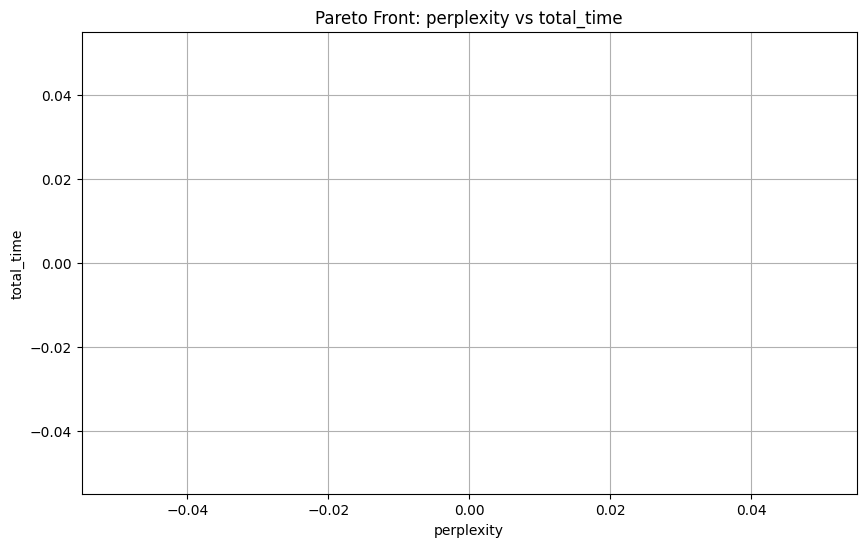

HuggingFaceTB/SmolLM-135M missed evaluation.
HuggingFaceTB/SmolLM2-135M missed evaluation.
HuggingFaceTB/SmolLM-360M missed evaluation.
HuggingFaceTB/SmolLM2-360M missed evaluation.
[]


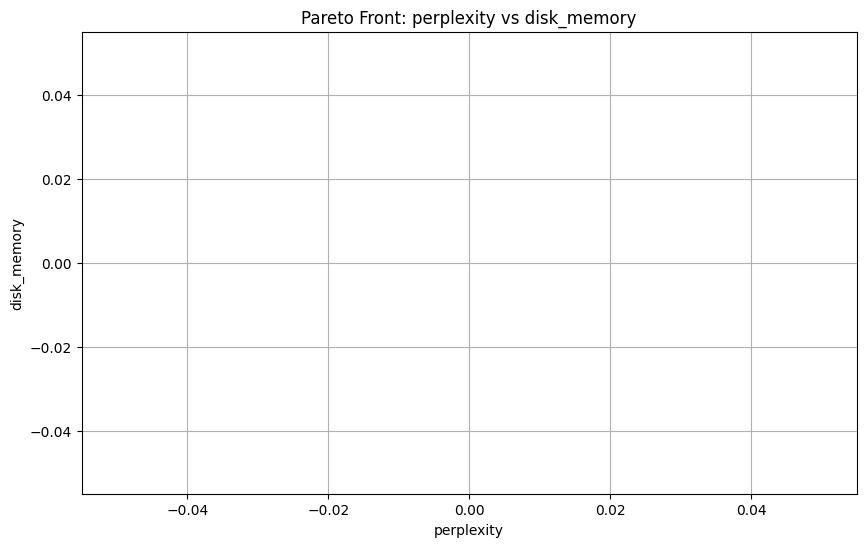

HuggingFaceTB/SmolLM-135M missed evaluation.
HuggingFaceTB/SmolLM2-135M missed evaluation.
HuggingFaceTB/SmolLM-360M missed evaluation.
HuggingFaceTB/SmolLM2-360M missed evaluation.
[]


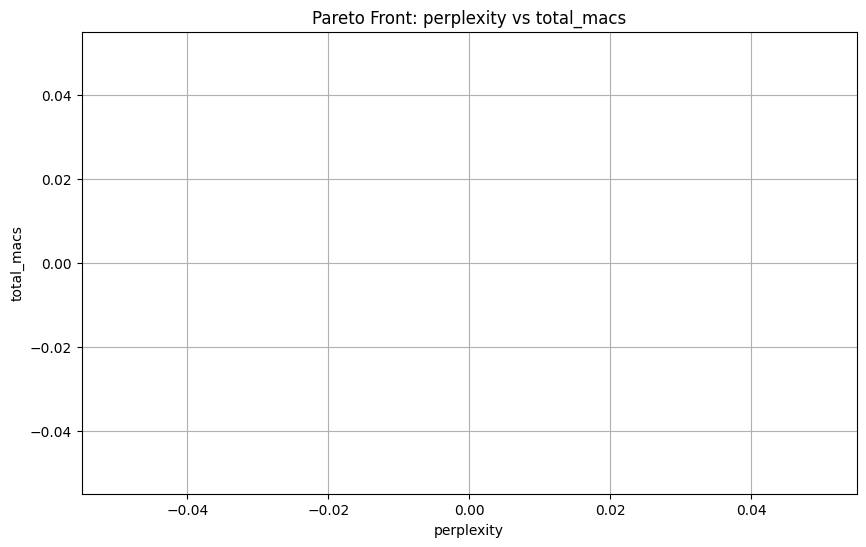

IndexError: list index out of range

In [21]:
create_pareto_front(perplexity_results, latency_results, "perplexity", "total_time")
create_pareto_front(perplexity_results, memory_results, "perplexity", "disk_memory")
create_pareto_front(perplexity_results, compute_results, "perplexity", "total_macs")
create_pareto_front(latency_results, energy_results, "total_time", "energy_consumed")

## Conclusion: What We've Learned About Measuring LLM Efficiency

In this module, we explored how to measure the efficiency of LLMs. Here’s a recap of the key concepts:

- **Efficiency Metrics Dimensions:**
    - Quality: Even if it might be difficult to measure, it is important to have a metric to evaluate and then adapt it to the needs of the application.
    - Memory: Memory influences the cost and resource usage of the model. A high memory usage can be a problem for real-world deployment.
    - Compute: Models with high compute requirements can be expensive to run and have a high carbon footprint.
    - Latency: The reponse speed of the model is critical for real-world use-cases.
    - Energy: To save costs and reduce the carbon footprint of the model, it is important to consider the energy consumption of the model.
- **Deployment Considerations:**
    - The trade-offs between the different metrics are not always clear.
    - The Pareto front can be used to identify the best trade-offs between the different metrics. Based on your use-case, you can select the best model for your needs.


### Next Steps: Quantization

Now that you understand how to measure the efficiency of LLMs, the next segment will focus on **quantization**. You’ll learn about quantization methods and how bit precision influences the efficiency of the model.

👉 **Continue to the next notebook:**  
[04-benchmark_llm_quantization_methods.ipynb on GitHub](https://github.com/PrunaAI/ai-efficiency-courses/blob/main/exercises/04-benchmark_llm_quantization_methods.ipynb)

## ⭐ Bonus Exercise: Measure LLM Efficiency across Context Lengths

As a bonus, extend your analysis to explore how LLM efficiency changes when the context length varies. Context length determines how many tokens a model can process at once, and it has a significant impact on quality, latency, compute, and memory usage. By analyzing efficiency across different context lengths, you’ll uncover how models scale with longer inputs.

**Your tasks:**

1. Benchmark models across different context lengths:
    Modify the evaluation function and run the models with varying context lengths.
2.	Compare scaling behavior:
    Identify how different model types and sizes handle longer contexts, and plot the results to visualize scaling trends.

**Questions:**
- Which model handles longer contexts most efficiently?
- How do quality and efficiency trade-offs evolve as context length increases?